In [33]:
import shutil, os
if os.path.exists('deep_learning_project'):
    shutil.rmtree('deep_learning_project')
    print("Deleted deep_learning_project")
else:
    print("Folder not found, nothing to delete")

Deleted deep_learning_project


In [34]:
!git clone https://github.com/samarthsingh1/deep_learning_project

Cloning into 'deep_learning_project'...
remote: Enumerating objects: 543, done.
remote: Counting objects: 100% (171/171), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 543 (delta 85), reused 59 (delta 45), pack-reused 372 (from 1)
Receiving objects: 100% (543/543), 48.86 MiB | 54.09 MiB/s, done.
Resolving deltas: 100% (186/186), done.


In [35]:
# =========================================================
# LOAD ALL PREDICTIONS FROM SAVED FILES
# =========================================================
# All predictions were saved as .npy files from the
# baselines, transformers, and informer notebooks.
# This avoids re-running any training during evaluation.
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

PRED_BASE = '/content/deep_learning_project/predictions'

# --- Reconstruct scaler ---
scaler = StandardScaler()
scaler.mean_ = np.load(f'{PRED_BASE}/baseline/scaler_mean.npy')
scaler.scale_ = np.load(f'{PRED_BASE}/baseline/scaler_scale.npy')
scaler.n_features_in_ = 1
scaler.var_ = scaler.scale_ ** 2

# --- Load test dates ---
test_dates = pd.to_datetime(pd.read_csv(f'{PRED_BASE}/baseline/test_dates.csv').iloc[:, 0])

# --- Load actuals ---
y_test_scaled = np.load(f'{PRED_BASE}/baseline/y_test_scaled.npy')

# --- Load baseline predictions ---
naive_persistence_preds_scaled = np.load(f'{PRED_BASE}/baseline/naive_persistence_preds_scaled.npy')
seasonal_naive_day_preds_scaled = np.load(f'{PRED_BASE}/baseline/seasonal_naive_day_preds_scaled.npy')
seasonal_naive_week_preds_scaled = np.load(f'{PRED_BASE}/baseline/seasonal_naive_week_preds_scaled.npy')
univariate_lstm_preds_scaled = np.load(f'{PRED_BASE}/baseline/univariate_lstm_preds_scaled.npy')
multivariate_lstm_preds_scaled = np.load(f'{PRED_BASE}/baseline/multivariate_lstm_preds_scaled.npy')
prob_lstm_all_preds_scaled = np.load(f'{PRED_BASE}/baseline/prob_lstm_all_preds_scaled.npy')
hw_preds_scaled = np.load(f'{PRED_BASE}/baseline/hw_preds_scaled.npy')
# --- Load fine-tuned Probabilistic LSTM predictions ---
prob_lstm_ft_preds = np.load(f'{PRED_BASE}/baseline/prob_lstm_ft_preds.npy')

# --- Load LSTM tuning results ---
# lstm_tuning_df = pd.read_csv(f'{PRED_BASE}/baseline/lstm_tuning_results.csv', index_col=0)

# --- Load transformer predictions ---
transformer_all_preds = np.load(f'{PRED_BASE}/transformer/transformer_all_preds.npy')
ft_all_preds = np.load(f'{PRED_BASE}/transformer/ft_all_preds.npy')

# --- Load informer predictions ---
inf_all_preds = np.load(f'{PRED_BASE}/informer/inf_all_preds.npy')

# --- Load loss curves ---
train_losses = np.load(f'{PRED_BASE}/transformer/train_losses.npy')
val_losses = np.load(f'{PRED_BASE}/transformer/val_losses.npy')
ft_train_losses = np.load(f'{PRED_BASE}/transformer/ft_train_losses.npy')
ft_val_losses = np.load(f'{PRED_BASE}/transformer/ft_val_losses.npy')
inf_train_losses = np.load(f'{PRED_BASE}/informer/inf_train_losses.npy')
inf_val_losses = np.load(f'{PRED_BASE}/informer/inf_val_losses.npy')

# --- Load tuning/ablation results ---
tuning_df = pd.read_csv(f'{PRED_BASE}/transformer/tuning_results.csv', index_col=0)
ablation_feat_df = pd.read_csv(f'{PRED_BASE}/transformer/ablation_features.csv')
window_df = pd.read_csv(f'{PRED_BASE}/transformer/ablation_windows.csv')

print("All predictions loaded successfully!")
print(f"Test samples:        {y_test_scaled.shape[0]}")
print(f"Transformer preds:   {transformer_all_preds.shape}")
print(f"Fine-tuned preds:    {ft_all_preds.shape}")
print(f"Informer preds:      {inf_all_preds.shape}")
print(f"Prob LSTM preds:     {prob_lstm_all_preds_scaled.shape}")
print(f"Holt-Winters preds:  {hw_preds_scaled.shape}")
print(f"Prob LSTM FT preds:  {prob_lstm_ft_preds.shape}")

All predictions loaded successfully!
Test samples:        5070
Transformer preds:   (5070, 24, 3)
Fine-tuned preds:    (5070, 24, 3)
Informer preds:      (5070, 24, 3)
Prob LSTM preds:     (5070, 24, 3)
Holt-Winters preds:  (5070, 24)
Prob LSTM FT preds:  (5070, 24, 3)


In [36]:
# =========================================================
# METRIC FUNCTIONS AND INVERSE TRANSFORM
# =========================================================

def mean_absolute_error(actual, predicted):
    return float(np.mean(np.abs(actual - predicted)))

def root_mean_squared_error(actual, predicted):
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))

def mean_absolute_percentage_error(actual, predicted, eps=1e-8):
    denom = np.maximum(np.abs(actual), eps)
    return float(np.mean(np.abs((actual - predicted) / denom)) * 100.0)

def compute_point_metrics(actual, predicted):
    return {
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': root_mean_squared_error(actual, predicted),
        'MAPE (%)': mean_absolute_percentage_error(actual, predicted),
    }

def inverse_transform_2d(sc, arr_2d):
    return sc.inverse_transform(arr_2d.reshape(-1, 1)).reshape(arr_2d.shape)

print("Metric functions defined.")

Metric functions defined.


In [37]:
# =========================================================
# INVERSE TRANSFORM ALL PREDICTIONS TO ORIGINAL SCALE
# =========================================================

# --- Actuals ---
actuals_orig = inverse_transform_2d(scaler, y_test_scaled)

# --- Naive baselines ---
naive_persistence_orig = inverse_transform_2d(scaler, naive_persistence_preds_scaled)
seasonal_day_orig = inverse_transform_2d(scaler, seasonal_naive_day_preds_scaled)
seasonal_week_orig = inverse_transform_2d(scaler, seasonal_naive_week_preds_scaled)

# --- Point-forecast LSTMs ---
uni_lstm_orig = inverse_transform_2d(scaler, univariate_lstm_preds_scaled)
multi_lstm_orig = inverse_transform_2d(scaler, multivariate_lstm_preds_scaled)

# --- Probabilistic LSTM ---
prob_lstm_q10_scaled = prob_lstm_all_preds_scaled[:, :, 0]
prob_lstm_q50_scaled = prob_lstm_all_preds_scaled[:, :, 1]
prob_lstm_q90_scaled = prob_lstm_all_preds_scaled[:, :, 2]

prob_lstm_q10_orig = inverse_transform_2d(scaler, prob_lstm_q10_scaled)
prob_lstm_q50_orig = inverse_transform_2d(scaler, prob_lstm_q50_scaled)
prob_lstm_q90_orig = inverse_transform_2d(scaler, prob_lstm_q90_scaled)

# --- Fine-Tuned Probabilistic LSTM ---
prob_lstm_ft_q10_scaled = prob_lstm_ft_preds[:, :, 0]
prob_lstm_ft_q50_scaled = prob_lstm_ft_preds[:, :, 1]
prob_lstm_ft_q90_scaled = prob_lstm_ft_preds[:, :, 2]

prob_lstm_ft_q10_orig = inverse_transform_2d(scaler, prob_lstm_ft_q10_scaled)
prob_lstm_ft_q50_orig = inverse_transform_2d(scaler, prob_lstm_ft_q50_scaled)
prob_lstm_ft_q90_orig = inverse_transform_2d(scaler, prob_lstm_ft_q90_scaled)

# --- Holt-Winters ---
hw_orig = inverse_transform_2d(scaler, hw_preds_scaled)

# --- Base Transformer ---
transformer_q10_scaled = transformer_all_preds[:, :, 0]
transformer_q50_scaled = transformer_all_preds[:, :, 1]
transformer_q90_scaled = transformer_all_preds[:, :, 2]

transformer_q10_orig = inverse_transform_2d(scaler, transformer_q10_scaled)
transformer_q50_orig = inverse_transform_2d(scaler, transformer_q50_scaled)
transformer_q90_orig = inverse_transform_2d(scaler, transformer_q90_scaled)

# --- Fine-Tuned Transformer ---
ft_q10_scaled = ft_all_preds[:, :, 0]
ft_q50_scaled = ft_all_preds[:, :, 1]
ft_q90_scaled = ft_all_preds[:, :, 2]

ft_q10_orig = inverse_transform_2d(scaler, ft_q10_scaled)
ft_q50_orig = inverse_transform_2d(scaler, ft_q50_scaled)
ft_q90_orig = inverse_transform_2d(scaler, ft_q90_scaled)

# --- Informer ---
inf_q10_scaled = inf_all_preds[:, :, 0]
inf_q50_scaled = inf_all_preds[:, :, 1]
inf_q90_scaled = inf_all_preds[:, :, 2]

inf_q10_orig = inverse_transform_2d(scaler, inf_q10_scaled)
inf_q50_orig = inverse_transform_2d(scaler, inf_q50_scaled)
inf_q90_orig = inverse_transform_2d(scaler, inf_q90_scaled)

print("All predictions inverse-transformed to original scale.")

All predictions inverse-transformed to original scale.


In [38]:
# =========================================================
# POINT FORECAST COMPARISON — ALL MODELS
# =========================================================

naive_metrics = compute_point_metrics(actuals_orig, naive_persistence_orig)
seasonal_day_metrics = compute_point_metrics(actuals_orig, seasonal_day_orig)
seasonal_week_metrics = compute_point_metrics(actuals_orig, seasonal_week_orig)
uni_lstm_metrics = compute_point_metrics(actuals_orig, uni_lstm_orig)
multi_lstm_metrics = compute_point_metrics(actuals_orig, multi_lstm_orig)
prob_lstm_metrics = compute_point_metrics(actuals_orig, prob_lstm_q50_orig)
prob_lstm_ft_metrics = compute_point_metrics(actuals_orig, prob_lstm_ft_q50_orig)
hw_metrics = compute_point_metrics(actuals_orig, hw_orig)
transformer_metrics = compute_point_metrics(actuals_orig, transformer_q50_orig)
ft_metrics = compute_point_metrics(actuals_orig, ft_q50_orig)
inf_metrics = compute_point_metrics(actuals_orig, inf_q50_orig)

all_results = {
    'Naive Persistence': naive_metrics,
    'Seasonal Naive Day': seasonal_day_metrics,
    'Seasonal Naive Week': seasonal_week_metrics,
    'Holt-Winters': hw_metrics,
    'Univariate LSTM': uni_lstm_metrics,
    'Multivariate LSTM': multi_lstm_metrics,
    'Probabilistic LSTM (q50)': prob_lstm_metrics,
    'Prob LSTM Fine-Tuned (q50)': prob_lstm_ft_metrics,
    'Transformer Base (q50)': transformer_metrics,
    'Transformer Fine-Tuned (q50)': ft_metrics,
    'Informer (q50)': inf_metrics,
}

comparison_rows = []
for model_name, metrics in all_results.items():
    row = {'Model': model_name}
    row.update(metrics)
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows).set_index('Model')

print("\n" + "=" * 80)
print("  POINT FORECAST COMPARISON — ALL MODELS")
print("=" * 80)
print(comparison_df.to_string(float_format='{:.2f}'.format))
print("=" * 80)


  POINT FORECAST COMPARISON — ALL MODELS
                                  MAE     RMSE  MAPE (%)
Model                                                   
Naive Persistence            35514.65 58203.16      3.82
Seasonal Naive Day           35514.65 58203.16      3.82
Seasonal Naive Week          59838.64 95700.00      5.79
Holt-Winters                 36185.87 59742.81      3.94
Univariate LSTM              37442.14 52527.29      4.23
Multivariate LSTM            34356.02 48107.95      3.81
Probabilistic LSTM (q50)     35276.25 51790.26      3.86
Prob LSTM Fine-Tuned (q50)   33935.07 50704.33      3.71
Transformer Base (q50)       38943.98 55748.14      4.11
Transformer Fine-Tuned (q50) 30641.08 45061.44      3.37
Informer (q50)               30530.60 45526.23      3.28


In [39]:
# =========================================================
# PROBABILISTIC METRICS — PICP, MIW, CALIBRATION
# =========================================================

def compute_probabilistic_metrics(actuals, q10, q50, q90, model_name):
    in_interval = ((actuals >= q10) & (actuals <= q90))
    picp = in_interval.mean() * 100
    miw = np.mean(q90 - q10)
    cal_q10 = (actuals < q10).mean() * 100
    cal_q50 = (actuals < q50).mean() * 100
    cal_q90 = (actuals < q90).mean() * 100
    return {
        'Model': model_name,
        'PICP (%)': picp,
        'MIW': miw,
        'q10 cal (target 10%)': cal_q10,
        'q50 cal (target 50%)': cal_q50,
        'q90 cal (target 90%)': cal_q90,
    }

prob_metrics_list = [
    compute_probabilistic_metrics(actuals_orig, prob_lstm_q10_orig, prob_lstm_q50_orig, prob_lstm_q90_orig, 'Probabilistic LSTM'),
    compute_probabilistic_metrics(actuals_orig, prob_lstm_ft_q10_orig, prob_lstm_ft_q50_orig, prob_lstm_ft_q90_orig, 'Prob LSTM Fine-Tuned'),
    compute_probabilistic_metrics(actuals_orig, transformer_q10_orig, transformer_q50_orig, transformer_q90_orig, 'Transformer Base'),
    compute_probabilistic_metrics(actuals_orig, ft_q10_orig, ft_q50_orig, ft_q90_orig, 'Transformer Fine-Tuned'),
    compute_probabilistic_metrics(actuals_orig, inf_q10_orig, inf_q50_orig, inf_q90_orig, 'Informer'),
]

prob_df = pd.DataFrame(prob_metrics_list).set_index('Model')

print("\n" + "=" * 80)
print("  PROBABILISTIC METRICS — PICP, MIW, CALIBRATION")
print("=" * 80)
print(prob_df.to_string(float_format='{:.2f}'.format))
print("=" * 80)


  PROBABILISTIC METRICS — PICP, MIW, CALIBRATION
                        PICP (%)       MIW  q10 cal (target 10%)  q50 cal (target 50%)  q90 cal (target 90%)
Model                                                                                                       
Probabilistic LSTM         89.36 138103.62                  3.40                 35.48                 92.75
Prob LSTM Fine-Tuned       85.38 118266.00                  7.71                 49.64                 93.09
Transformer Base           86.28 154329.17                 10.25                 63.57                 96.53
Transformer Fine-Tuned     91.49 138289.80                  4.86                 54.45                 96.35
Informer                   95.00 158028.48                  2.69                 44.84                 97.69


In [40]:
# =========================================================
# PER-QUANTILE PINBALL LOSS
# =========================================================

def compute_pinball_loss(actuals, predictions, quantile):
    errors = actuals - predictions
    return np.mean(np.maximum(quantile * errors, (quantile - 1) * errors))

def compute_all_pinball_losses(actuals, q10, q50, q90, model_name):
    pl_10 = compute_pinball_loss(actuals, q10, 0.1)
    pl_50 = compute_pinball_loss(actuals, q50, 0.5)
    pl_90 = compute_pinball_loss(actuals, q90, 0.9)
    return {
        'Model': model_name,
        'Pinball q10': pl_10,
        'Pinball q50': pl_50,
        'Pinball q90': pl_90,
        'Pinball Avg': (pl_10 + pl_50 + pl_90) / 3,
    }

pinball_list = [
    compute_all_pinball_losses(actuals_orig, prob_lstm_q10_orig, prob_lstm_q50_orig, prob_lstm_q90_orig, 'Probabilistic LSTM'),
    compute_all_pinball_losses(actuals_orig, prob_lstm_ft_q10_orig, prob_lstm_ft_q50_orig, prob_lstm_ft_q90_orig, 'Prob LSTM Fine-Tuned'),
    compute_all_pinball_losses(actuals_orig, transformer_q10_orig, transformer_q50_orig, transformer_q90_orig, 'Transformer Base'),
    compute_all_pinball_losses(actuals_orig, ft_q10_orig, ft_q50_orig, ft_q90_orig, 'Transformer Fine-Tuned'),
    compute_all_pinball_losses(actuals_orig, inf_q10_orig, inf_q50_orig, inf_q90_orig, 'Informer'),
]

pinball_df = pd.DataFrame(pinball_list).set_index('Model')

print("\n" + "=" * 80)
print("  PER-QUANTILE PINBALL LOSS (lower is better)")
print("=" * 80)
print(pinball_df.to_string(float_format='{:.2f}'.format))
print("=" * 80)


  PER-QUANTILE PINBALL LOSS (lower is better)
                        Pinball q10  Pinball q50  Pinball q90  Pinball Avg
Model                                                                     
Probabilistic LSTM          9450.20     17638.13      8589.56     11892.63
Prob LSTM Fine-Tuned        8157.58     16967.54      8649.75     11258.29
Transformer Base            8724.50     19471.99     10934.91     13043.80
Transformer Fine-Tuned      7935.65     15320.54      8878.50     10711.56
Informer                    8890.94     15265.30      9117.89     11091.38


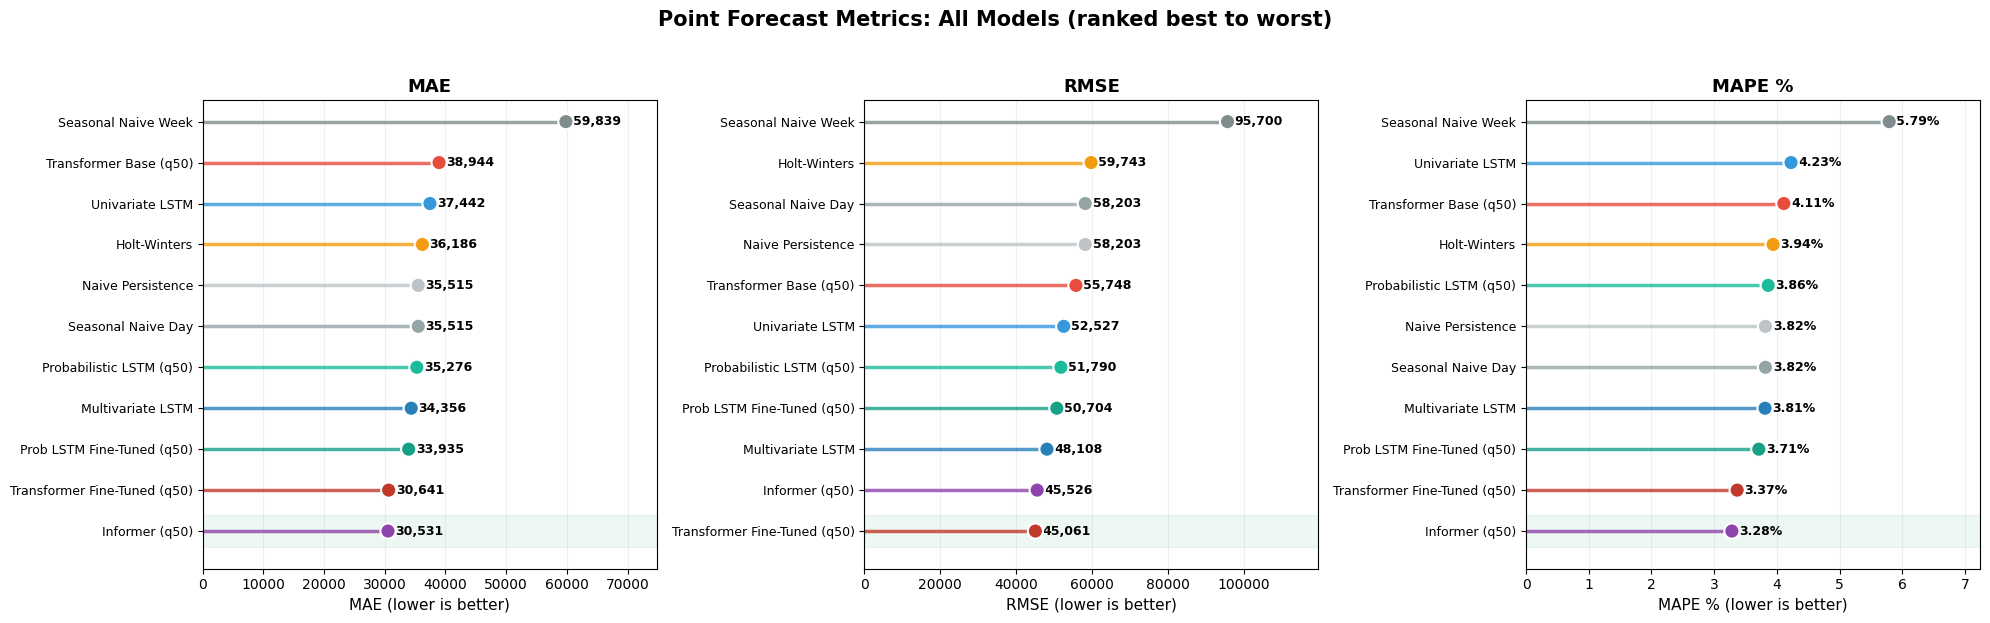

In [41]:
# =========================================================
# POINT FORECAST METRICS — LOLLIPOP CHART
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

color_map = {
    'Naive Persistence': '#bdc3c7',
    'Seasonal Naive Day': '#95a5a6',
    'Seasonal Naive Week': '#7f8c8d',
    'Holt-Winters': '#f39c12',
    'Univariate LSTM': '#3498db',
    'Multivariate LSTM': '#2980b9',
    'Probabilistic LSTM (q50)': '#1abc9c',
    'Prob LSTM Fine-Tuned (q50)': '#16a085',
    'Transformer Base (q50)': '#e74c3c',
    'Transformer Fine-Tuned (q50)': '#c0392b',
    'Informer (q50)': '#8e44ad',
}

metrics_list = [('MAE', 'MAE (lower is better)'),
                ('RMSE', 'RMSE (lower is better)'),
                ('MAPE (%)', 'MAPE % (lower is better)')]

for ax, (metric_key, metric_label) in zip(axes, metrics_list):
    sorted_models = sorted(all_results.keys(), key=lambda m: all_results[m][metric_key])
    vals = [all_results[m][metric_key] for m in sorted_models]
    colors = [color_map[m] for m in sorted_models]

    y_pos = range(len(sorted_models))
    ax.hlines(y=y_pos, xmin=0, xmax=vals, color=colors, linewidth=2.5, alpha=0.8)
    ax.scatter(vals, y_pos, color=colors, s=120, zorder=5, edgecolors='white', linewidths=1.5)

    for i, (val, name) in enumerate(zip(vals, sorted_models)):
        if metric_key == 'MAPE (%)':
            label = f'{val:.2f}%'
        else:
            label = f'{val:,.0f}'
        ax.text(val + max(vals) * 0.02, i, label, va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(sorted_models, fontsize=9)
    ax.set_xlabel(metric_label, fontsize=11)
    ax.set_title(metric_label.split(' (')[0], fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.2, axis='x')
    ax.set_xlim(0, max(vals) * 1.25)
    ax.axhspan(-0.4, 0.4, color='#27ae60', alpha=0.08)

plt.suptitle('Point Forecast Metrics: All Models (ranked best to worst)',
             fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

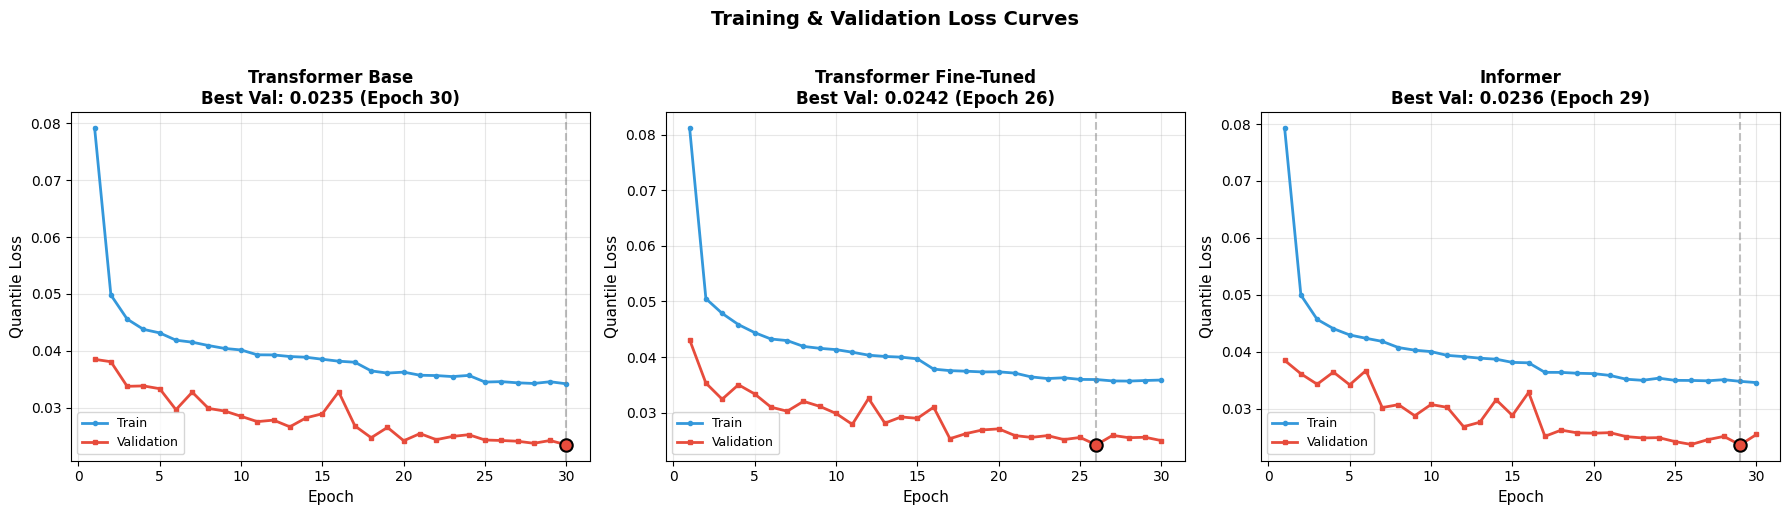

In [42]:
# =========================================================
# TRAINING & VALIDATION LOSS CURVES — ALL DL MODELS
# =========================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

curves = [
    (train_losses, val_losses, 'Transformer Base'),
    (ft_train_losses, ft_val_losses, 'Transformer Fine-Tuned'),
    (inf_train_losses, inf_val_losses, 'Informer'),
]

for ax, (t_loss, v_loss, name) in zip(axes, curves):
    epochs = range(1, len(t_loss) + 1)
    ax.plot(epochs, t_loss, label='Train', color='#3498db', linewidth=2, marker='o', markersize=3)
    ax.plot(epochs, v_loss, label='Validation', color='#e74c3c', linewidth=2, marker='s', markersize=3)

    best_ep = np.argmin(v_loss) + 1
    best_v = min(v_loss)
    ax.axvline(x=best_ep, color='gray', linestyle='--', alpha=0.5)
    ax.scatter([best_ep], [best_v], color='#e74c3c', s=80, zorder=5,
               edgecolors='black', linewidths=1.5)

    ax.set_xlabel('Epoch', fontsize=11)
    ax.set_ylabel('Quantile Loss', fontsize=11)
    ax.set_title(f'{name}\nBest Val: {best_v:.4f} (Epoch {best_ep})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

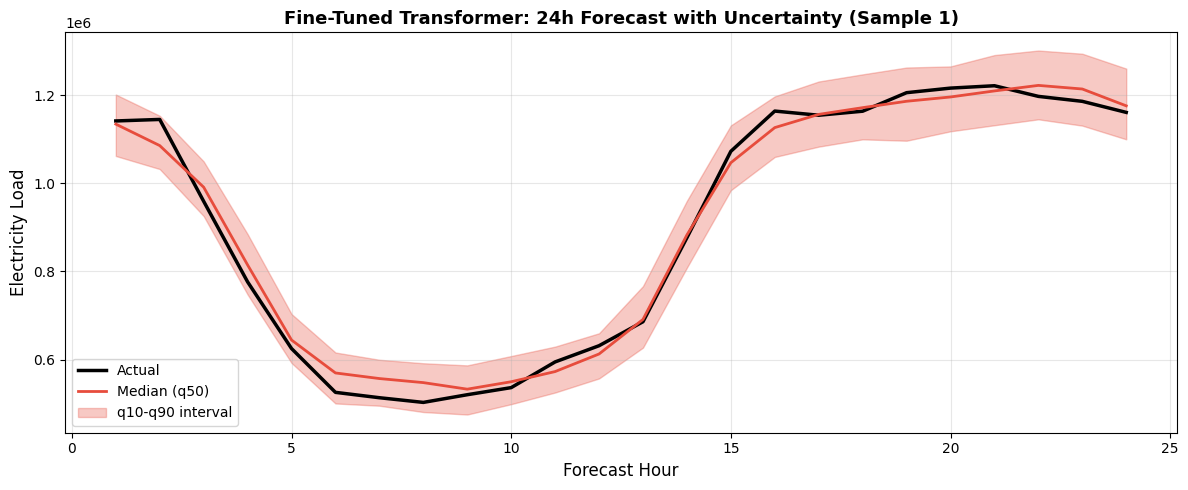

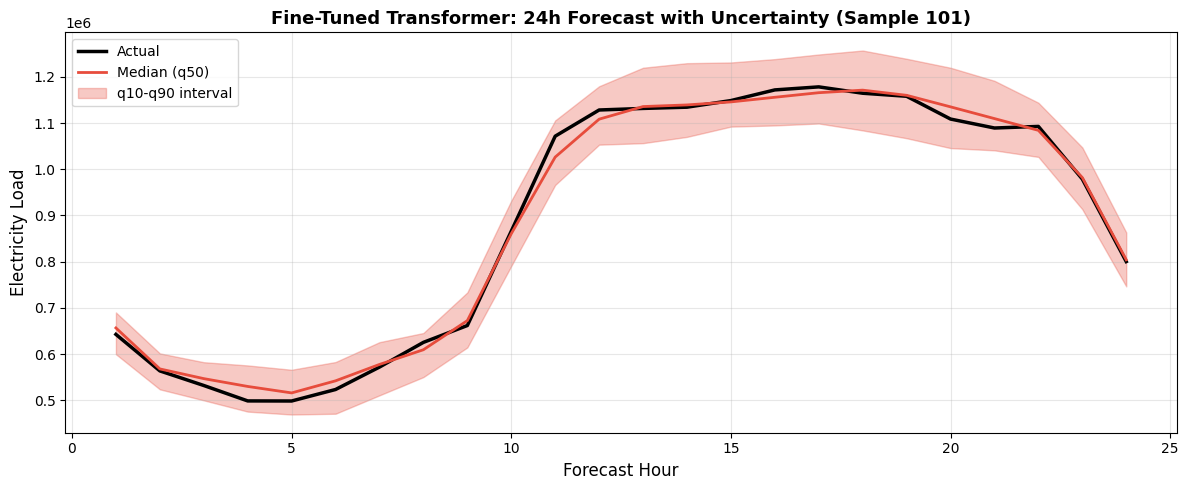

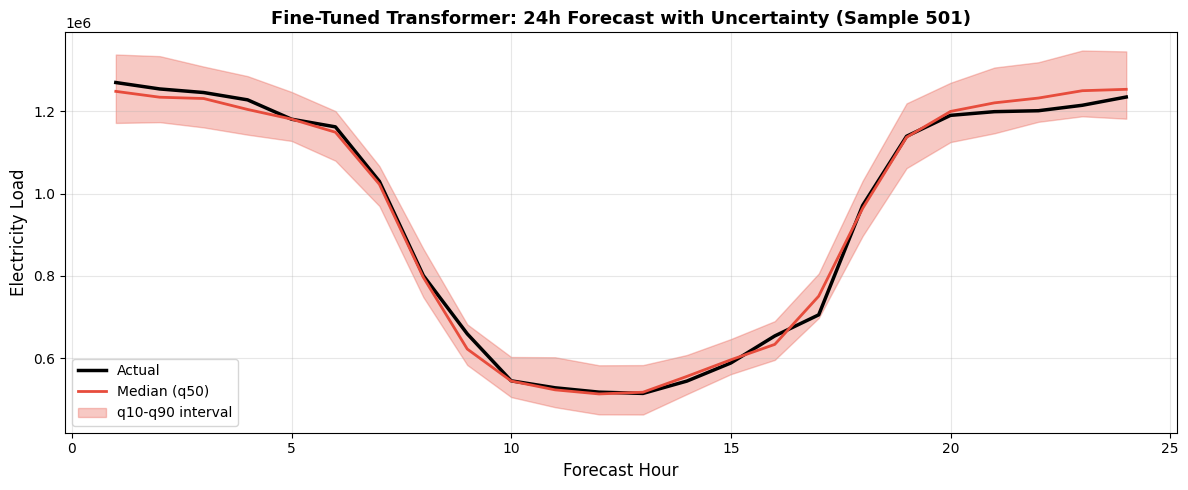

In [43]:
# =========================================================
# UNCERTAINTY BAND PLOTS
# =========================================================

def plot_uncertainty_bands(actuals, q10, q50, q90, sample_idx, model_name, title_suffix=""):
    hours = np.arange(1, 25)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(hours, actuals[sample_idx], label='Actual', color='black', linewidth=2.5)
    ax.plot(hours, q50[sample_idx], label='Median (q50)', color='#e74c3c', linewidth=2)
    ax.fill_between(hours, q10[sample_idx], q90[sample_idx],
                    alpha=0.3, color='#e74c3c', label='q10-q90 interval')
    ax.set_xlabel('Forecast Hour', fontsize=12)
    ax.set_ylabel('Electricity Load', fontsize=12)
    ax.set_title(f'{model_name}: 24h Forecast with Uncertainty {title_suffix}',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_uncertainty_bands(actuals_orig, ft_q10_orig, ft_q50_orig, ft_q90_orig,
                       0, 'Fine-Tuned Transformer', '(Sample 1)')
plot_uncertainty_bands(actuals_orig, ft_q10_orig, ft_q50_orig, ft_q90_orig,
                       100, 'Fine-Tuned Transformer', '(Sample 101)')
plot_uncertainty_bands(actuals_orig, ft_q10_orig, ft_q50_orig, ft_q90_orig,
                       500, 'Fine-Tuned Transformer', '(Sample 501)')

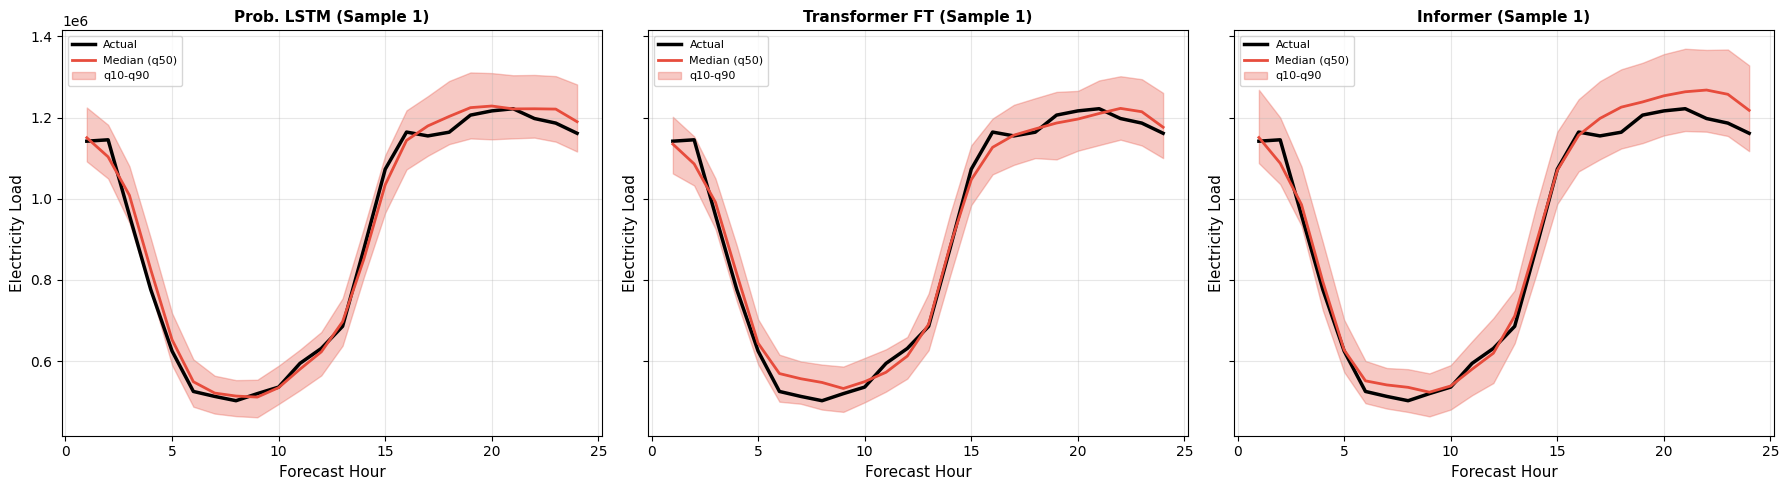

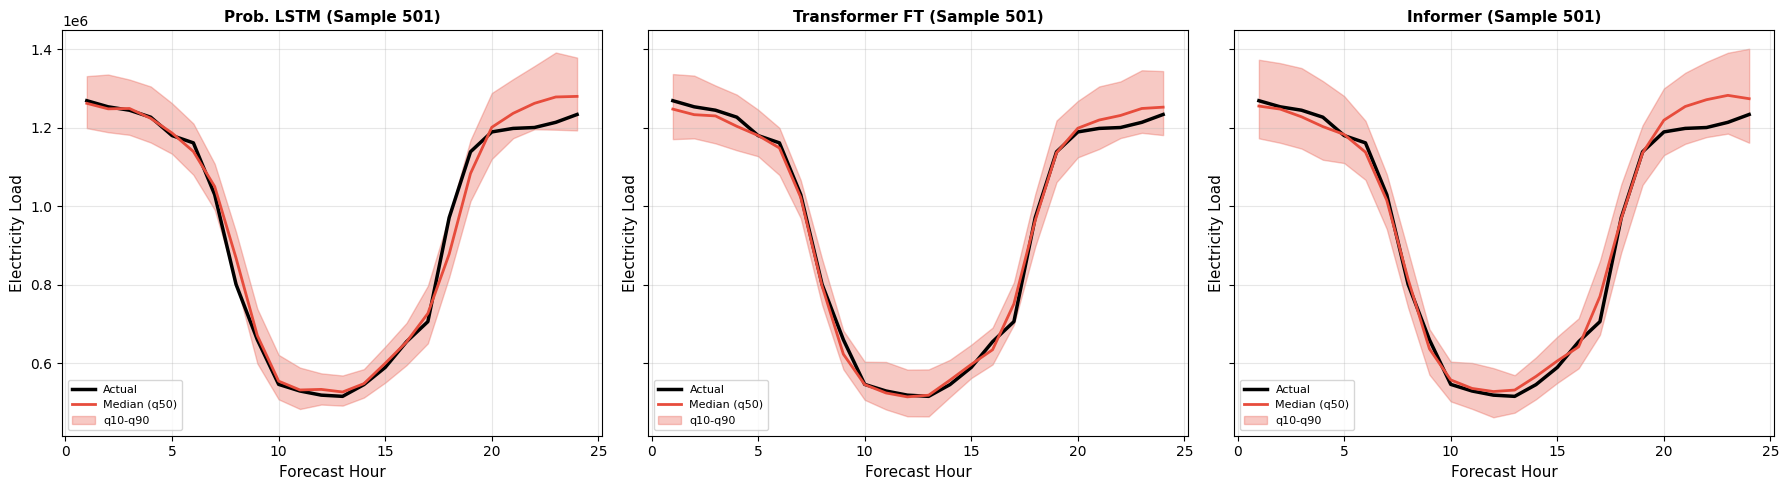

In [44]:
# =========================================================
# SIDE-BY-SIDE PROBABILISTIC COMPARISON
# =========================================================

def plot_side_by_side_bands(actuals, models_data, sample_idx, title_suffix=""):
    hours = np.arange(1, 25)
    n_models = len(models_data)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)

    for ax, (name, q10, q50, q90) in zip(axes, models_data):
        ax.plot(hours, actuals[sample_idx], label='Actual', color='black', linewidth=2.5)
        ax.plot(hours, q50[sample_idx], label='Median (q50)', color='#e74c3c', linewidth=2)
        ax.fill_between(hours, q10[sample_idx], q90[sample_idx],
                        alpha=0.3, color='#e74c3c', label='q10-q90')
        ax.set_xlabel('Forecast Hour', fontsize=11)
        ax.set_ylabel('Electricity Load', fontsize=11)
        ax.set_title(f'{name} {title_suffix}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

models_data = [
    ('Prob. LSTM', prob_lstm_q10_orig, prob_lstm_q50_orig, prob_lstm_q90_orig),
    ('Transformer FT', ft_q10_orig, ft_q50_orig, ft_q90_orig),
    ('Informer', inf_q10_orig, inf_q50_orig, inf_q90_orig),
]

plot_side_by_side_bands(actuals_orig, models_data, 0, '(Sample 1)')
plot_side_by_side_bands(actuals_orig, models_data, 500, '(Sample 501)')

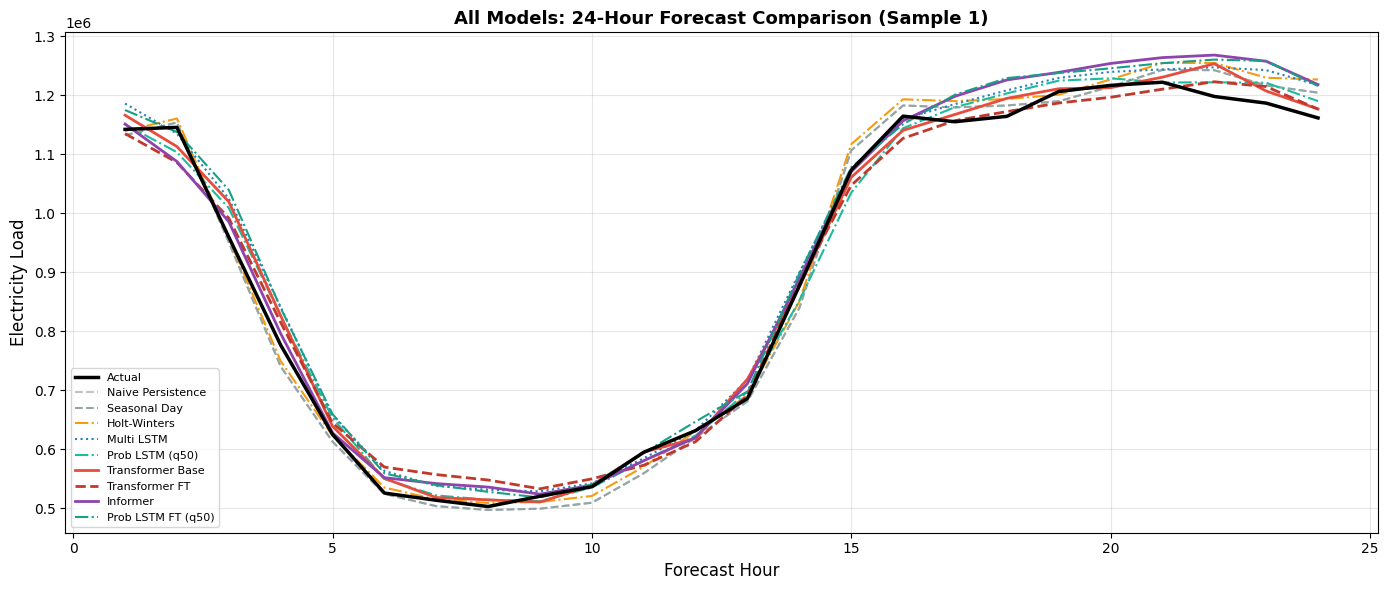

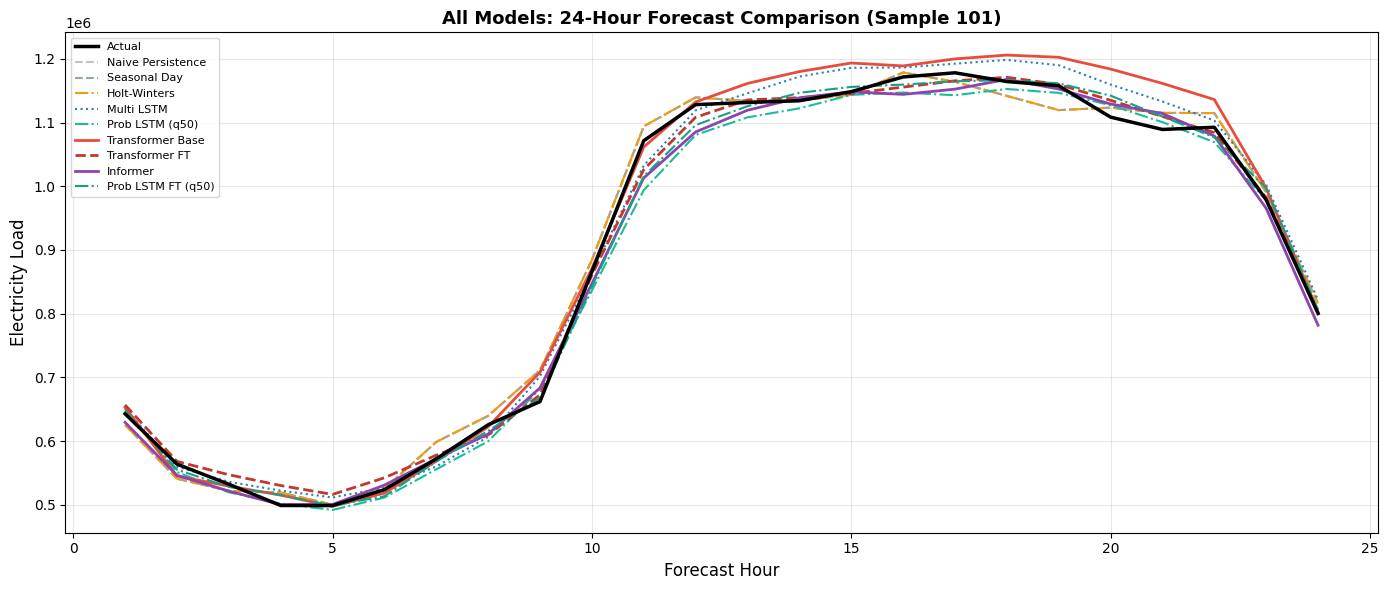

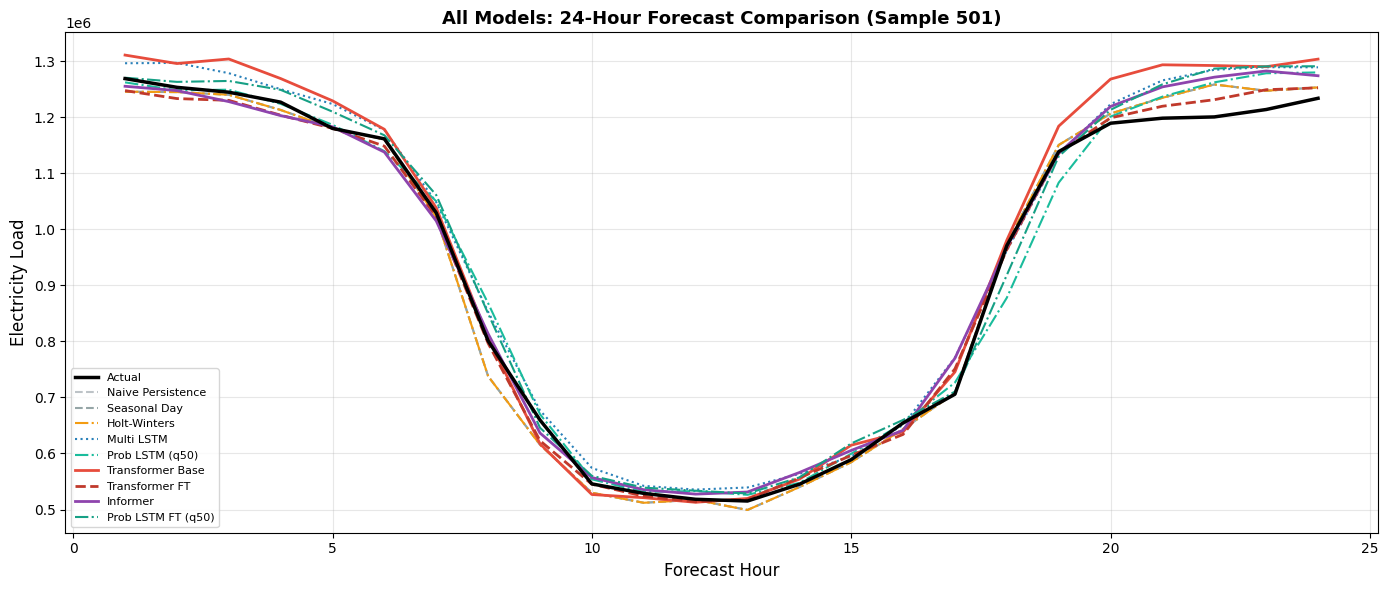

In [45]:
# =========================================================
# ALL MODELS — 24H FORECAST OVERLAY
# =========================================================

FORECAST_HORIZON = 24

def plot_all_models_comparison(sample_idx=0):
    hours = np.arange(1, FORECAST_HORIZON + 1)
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.plot(hours, actuals_orig[sample_idx], label='Actual', color='black', linewidth=2.5, zorder=5)
    ax.plot(hours, naive_persistence_orig[sample_idx], label='Naive Persistence', color='#bdc3c7', linewidth=1.5, linestyle='--')
    ax.plot(hours, seasonal_day_orig[sample_idx], label='Seasonal Day', color='#95a5a6', linewidth=1.5, linestyle='--')
    ax.plot(hours, hw_orig[sample_idx], label='Holt-Winters', color='#f39c12', linewidth=1.5, linestyle='-.')
    ax.plot(hours, multi_lstm_orig[sample_idx], label='Multi LSTM', color='#2980b9', linewidth=1.5, linestyle=':')
    ax.plot(hours, prob_lstm_q50_orig[sample_idx], label='Prob LSTM (q50)', color='#1abc9c', linewidth=1.5, linestyle='-.')
    ax.plot(hours, transformer_q50_orig[sample_idx], label='Transformer Base', color='#e74c3c', linewidth=2)
    ax.plot(hours, ft_q50_orig[sample_idx], label='Transformer FT', color='#c0392b', linewidth=2, linestyle='--')
    ax.plot(hours, inf_q50_orig[sample_idx], label='Informer', color='#8e44ad', linewidth=2)
    ax.plot(hours, prob_lstm_ft_q50_orig[sample_idx], label='Prob LSTM FT (q50)', color='#16a085', linewidth=1.5, linestyle='-.')

    ax.set_xlabel('Forecast Hour', fontsize=12)
    ax.set_ylabel('Electricity Load', fontsize=12)
    ax.set_title(f'All Models: 24-Hour Forecast Comparison (Sample {sample_idx+1})', fontsize=13, fontweight='bold')
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_all_models_comparison(0)
plot_all_models_comparison(100)
plot_all_models_comparison(500)

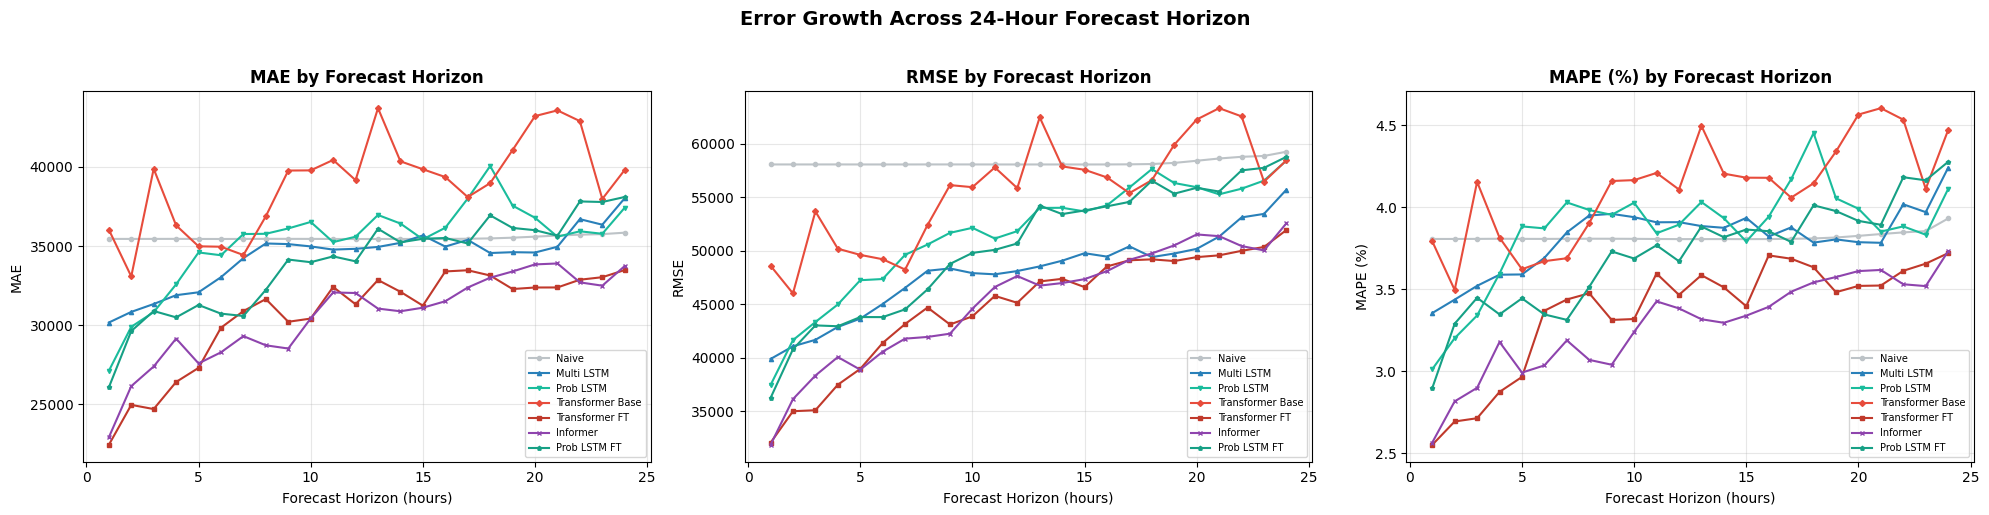

In [46]:
# =========================================================
# HORIZON-WISE ERROR ANALYSIS
# =========================================================

def compute_horizon_metrics(actual_2d, pred_2d):
    rows = []
    for h in range(actual_2d.shape[1]):
        rows.append({
            'Horizon (h)': h + 1,
            'MAE': mean_absolute_error(actual_2d[:, h], pred_2d[:, h]),
            'RMSE': root_mean_squared_error(actual_2d[:, h], pred_2d[:, h]),
            'MAPE (%)': mean_absolute_percentage_error(actual_2d[:, h], pred_2d[:, h]),
        })
    return pd.DataFrame(rows)

hz_naive = compute_horizon_metrics(actuals_orig, naive_persistence_orig)
hz_multi = compute_horizon_metrics(actuals_orig, multi_lstm_orig)
hz_prob = compute_horizon_metrics(actuals_orig, prob_lstm_q50_orig)
hz_tf = compute_horizon_metrics(actuals_orig, transformer_q50_orig)
hz_ft = compute_horizon_metrics(actuals_orig, ft_q50_orig)
hz_inf = compute_horizon_metrics(actuals_orig, inf_q50_orig)
hz_prob_ft = compute_horizon_metrics(actuals_orig, prob_lstm_ft_q50_orig)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, metric in zip(axes, ['MAE', 'RMSE', 'MAPE (%)']):
    ax.plot(hz_naive['Horizon (h)'], hz_naive[metric], label='Naive', color='#bdc3c7', marker='o', markersize=3)
    ax.plot(hz_multi['Horizon (h)'], hz_multi[metric], label='Multi LSTM', color='#2980b9', marker='^', markersize=3)
    ax.plot(hz_prob['Horizon (h)'], hz_prob[metric], label='Prob LSTM', color='#1abc9c', marker='v', markersize=3)
    ax.plot(hz_tf['Horizon (h)'], hz_tf[metric], label='Transformer Base', color='#e74c3c', marker='D', markersize=3)
    ax.plot(hz_ft['Horizon (h)'], hz_ft[metric], label='Transformer FT', color='#c0392b', marker='s', markersize=3)
    ax.plot(hz_inf['Horizon (h)'], hz_inf[metric], label='Informer', color='#8e44ad', marker='x', markersize=3)
    ax.plot(hz_prob_ft['Horizon (h)'], hz_prob_ft[metric], label='Prob LSTM FT', color='#16a085', marker='p', markersize=3)
    ax.set_xlabel('Forecast Horizon (hours)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Forecast Horizon', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Error Growth Across 24-Hour Forecast Horizon', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [47]:
# =========================================================
# WEEKDAY VS WEEKEND ERROR ANALYSIS
# =========================================================

INPUT_WINDOW = 168
is_weekend_mask = test_dates.dt.dayofweek >= 5
weekday_idx = np.where(~is_weekend_mask)[0]
weekend_idx = np.where(is_weekend_mask)[0]

def compute_split_metrics(actuals, predicted, indices, label):
    return {
        'Segment': label,
        'MAE': mean_absolute_error(actuals[indices], predicted[indices]),
        'RMSE': root_mean_squared_error(actuals[indices], predicted[indices]),
        'MAPE (%)': mean_absolute_percentage_error(actuals[indices], predicted[indices]),
    }

models_for_split = {
    'Naive Persistence': naive_persistence_orig,
    'Multivariate LSTM': multi_lstm_orig,
    'Prob. LSTM (q50)': prob_lstm_q50_orig,
    'Prob LSTM FT (q50)': prob_lstm_ft_q50_orig,
    'Transformer Base (q50)': transformer_q50_orig,
    'Transformer FT (q50)': ft_q50_orig,
    'Informer (q50)': inf_q50_orig,
}

split_rows = []
for name, preds in models_for_split.items():
    wd = compute_split_metrics(actuals_orig, preds, weekday_idx, 'Weekday')
    wd['Model'] = name
    we = compute_split_metrics(actuals_orig, preds, weekend_idx, 'Weekend')
    we['Model'] = name
    split_rows.extend([wd, we])

split_df = pd.DataFrame(split_rows)[['Model', 'Segment', 'MAE', 'RMSE', 'MAPE (%)']]

print("\n" + "=" * 80)
print("  WEEKDAY vs WEEKEND ERROR ANALYSIS")
print("=" * 80)
print(split_df.to_string(index=False, float_format='{:.2f}'.format))
print("=" * 80)


  WEEKDAY vs WEEKEND ERROR ANALYSIS
                 Model Segment      MAE     RMSE  MAPE (%)
     Naive Persistence Weekday 35614.57 61118.04      3.83
     Naive Persistence Weekend 35262.74 50108.35      3.78
     Multivariate LSTM Weekday 35159.91 49639.60      3.91
     Multivariate LSTM Weekend 32329.56 44011.02      3.57
      Prob. LSTM (q50) Weekday 36581.75 54548.59      4.01
      Prob. LSTM (q50) Weekend 31985.32 44077.50      3.49
    Prob LSTM FT (q50) Weekday 34663.41 52972.44      3.80
    Prob LSTM FT (q50) Weekend 32099.04 44476.44      3.50
Transformer Base (q50) Weekday 39290.35 56688.70      4.17
Transformer Base (q50) Weekend 38070.84 53303.54      3.95
  Transformer FT (q50) Weekday 31363.46 46584.75      3.47
  Transformer FT (q50) Weekend 28820.08 40970.85      3.10
        Informer (q50) Weekday 31327.28 47207.93      3.39
        Informer (q50) Weekend 28522.30 40981.81      3.02


In [48]:

# =========================================================
# SEASONAL ERROR ANALYSIS
# =========================================================

def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Fall'
    else: return 'Winter'

test_months = test_dates.dt.month
test_seasons = np.array([get_season(m) for m in test_months])

season_rows = []
for name, preds in models_for_split.items():
    for season in ['Spring', 'Summer', 'Fall', 'Winter']:
        idx = np.where(test_seasons == season)[0]
        if len(idx) == 0:
            continue
        m = compute_split_metrics(actuals_orig, preds, idx, season)
        m['Model'] = name
        season_rows.append(m)

season_df = pd.DataFrame(season_rows)[['Model', 'Segment', 'MAE', 'RMSE', 'MAPE (%)']]

print("\n" + "=" * 80)
print("  SEASONAL ERROR ANALYSIS")
print("=" * 80)
print(season_df.to_string(index=False, float_format='{:.2f}'.format))
print("=" * 80)


  SEASONAL ERROR ANALYSIS
                 Model Segment      MAE     RMSE  MAPE (%)
     Naive Persistence  Summer 37502.74 52098.24      3.39
     Naive Persistence    Fall 31439.65 45533.95      3.43
     Naive Persistence  Winter 41882.47 96857.93      6.25
     Multivariate LSTM  Summer 36183.88 47923.95      3.47
     Multivariate LSTM    Fall 31469.61 42160.45      3.55
     Multivariate LSTM  Winter 37608.70 63177.05      5.59
      Prob. LSTM (q50)  Summer 36974.72 50458.19      3.54
      Prob. LSTM (q50)    Fall 33301.34 44923.21      3.68
      Prob. LSTM (q50)  Winter 36159.58 71410.24      5.37
    Prob LSTM FT (q50)  Summer 35535.16 47964.26      3.43
    Prob LSTM FT (q50)    Fall 31428.43 43447.55      3.48
    Prob LSTM FT (q50)  Winter 36721.66 73810.63      5.24
Transformer Base (q50)  Summer 47869.69 64900.79      4.37
Transformer Base (q50)    Fall 31213.79 42969.14      3.44
Transformer Base (q50)  Winter 35574.82 60117.54      5.35
  Transformer FT (q50)  Summe

In [49]:
# =========================================================
# PEAK VS OFF-PEAK ANALYSIS
# =========================================================

test_hours = test_dates.dt.hour
is_peak_mask = (test_hours >= 9) & (test_hours <= 18)
peak_idx = np.where(is_peak_mask)[0]
offpeak_idx = np.where(~is_peak_mask)[0]

peak_rows = []
for name, preds in models_for_split.items():
    pk = compute_split_metrics(actuals_orig, preds, peak_idx, 'Peak (9am-6pm)')
    pk['Model'] = name
    op = compute_split_metrics(actuals_orig, preds, offpeak_idx, 'Off-Peak')
    op['Model'] = name
    peak_rows.extend([pk, op])

peak_df = pd.DataFrame(peak_rows)[['Model', 'Segment', 'MAE', 'RMSE', 'MAPE (%)']]

print("\n" + "=" * 80)
print("  PEAK vs OFF-PEAK ERROR ANALYSIS")
print("=" * 80)
print(peak_df.to_string(index=False, float_format='{:.2f}'.format))
print("=" * 80)


  PEAK vs OFF-PEAK ERROR ANALYSIS
                 Model        Segment      MAE     RMSE  MAPE (%)
     Naive Persistence Peak (9am-6pm) 35471.59 58073.49      3.81
     Naive Persistence       Off-Peak 35545.35 58295.42      3.82
     Multivariate LSTM Peak (9am-6pm) 33792.39 47389.44      3.76
     Multivariate LSTM       Off-Peak 34757.80 48613.66      3.85
      Prob. LSTM (q50) Peak (9am-6pm) 34369.25 49882.71      3.77
      Prob. LSTM (q50)       Off-Peak 35922.80 53108.22      3.92
    Prob LSTM FT (q50) Peak (9am-6pm) 32129.56 47710.38      3.56
    Prob LSTM FT (q50)       Off-Peak 35222.12 52734.87      3.82
Transformer Base (q50) Peak (9am-6pm) 37091.82 52617.20      3.96
Transformer Base (q50)       Off-Peak 40264.27 57876.69      4.22
  Transformer FT (q50) Peak (9am-6pm) 29275.50 42853.91      3.26
  Transformer FT (q50)       Off-Peak 31614.52 46571.21      3.44
        Informer (q50) Peak (9am-6pm) 29357.83 43560.64      3.19
        Informer (q50)       Off-Peak 313

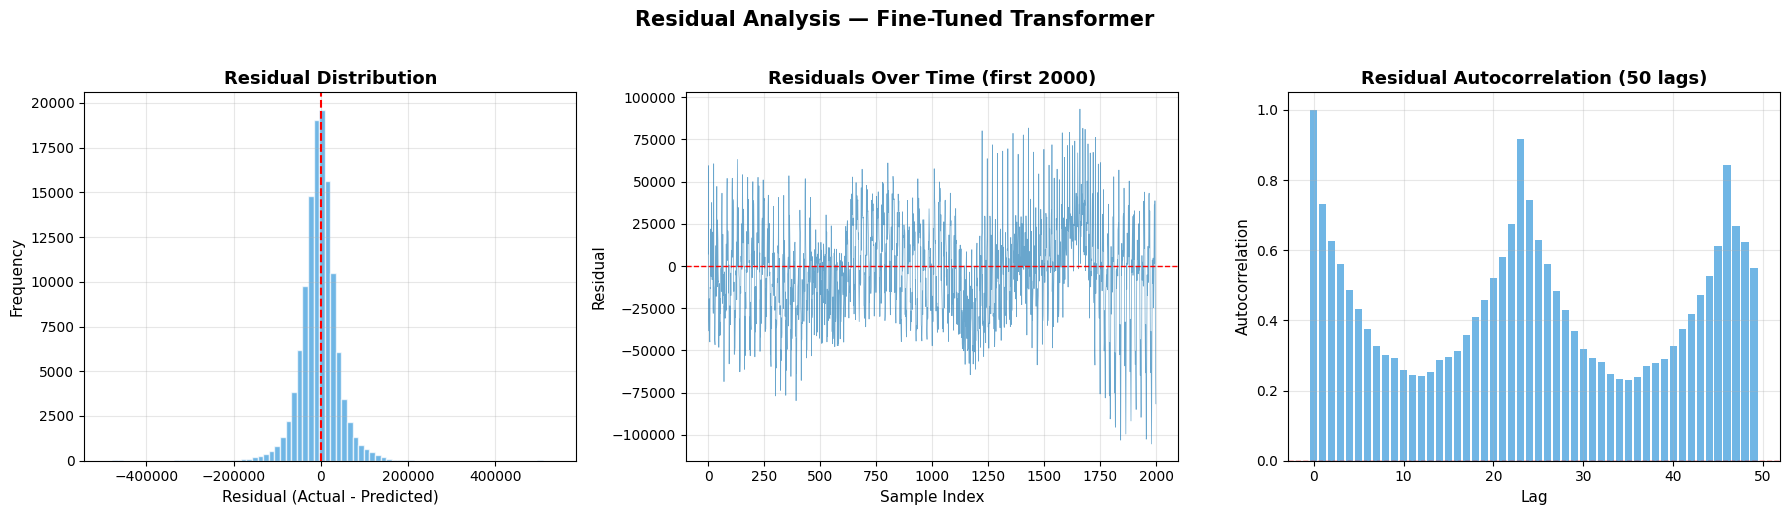

Residual mean: -4435.86
Residual std:  44842.57


In [50]:
# =========================================================
# RESIDUAL ANALYSIS — FINE-TUNED TRANSFORMER
# =========================================================

residuals = (actuals_orig - ft_q50_orig).flatten()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(residuals, bins=80, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Residual (Actual - Predicted)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Residual Distribution', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(residuals[:2000], linewidth=0.5, color='#2980b9', alpha=0.7)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Sample Index', fontsize=11)
axes[1].set_ylabel('Residual', fontsize=11)
axes[1].set_title('Residuals Over Time (first 2000)', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

n = len(residuals)
acf = np.correlate(residuals - residuals.mean(), residuals - residuals.mean(), mode='full')
acf = acf[n-1:] / acf[n-1]
axes[2].bar(range(50), acf[:50], color='#3498db', alpha=0.7)
axes[2].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Lag', fontsize=11)
axes[2].set_ylabel('Autocorrelation', fontsize=11)
axes[2].set_title('Residual Autocorrelation (50 lags)', fontsize=13, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Residual Analysis — Fine-Tuned Transformer', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Residual mean: {residuals.mean():.2f}")
print(f"Residual std:  {residuals.std():.2f}")

In [51]:
# =========================================================
# STATISTICAL SIGNIFICANCE TEST (DIEBOLD-MARIANO)
# =========================================================

def diebold_mariano_test(actual, pred1, pred2):
    from scipy import stats
    e1 = np.abs(actual - pred1)
    e2 = np.abs(actual - pred2)
    d = (e1 - e2).flatten()
    n = len(d)
    d_mean = d.mean()
    d_var = np.var(d, ddof=1)
    dm_stat = d_mean / np.sqrt(d_var / n)
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return dm_stat, p_value

comparisons = [
    ('Naive Persistence', naive_persistence_orig),
    ('Multivariate LSTM', multi_lstm_orig),
    ('Prob. LSTM (q50)', prob_lstm_q50_orig),
    ('Prob LSTM FT (q50)', prob_lstm_ft_q50_orig),
    ('Transformer Base (q50)', transformer_q50_orig),
    ('Informer (q50)', inf_q50_orig),
]

print("\n" + "=" * 80)
print("  DIEBOLD-MARIANO TEST vs FINE-TUNED TRANSFORMER")
print("  H0: Equal forecast accuracy | Significance level: 0.05")
print("=" * 80)

for name, preds in comparisons:
    dm_stat, p_val = diebold_mariano_test(actuals_orig, preds, ft_q50_orig)
    sig = "YES" if p_val < 0.05 else "NO"
    direction = "FT Transformer better" if dm_stat > 0 else "Other model better"
    print(f"\n  vs {name}:")
    print(f"    DM Statistic: {dm_stat:+.4f}")
    print(f"    p-value:      {p_val:.6f}")
    print(f"    Significant:  {sig}")
    print(f"    Direction:    {direction}")

print("\n" + "=" * 80)


  DIEBOLD-MARIANO TEST vs FINE-TUNED TRANSFORMER
  H0: Equal forecast accuracy | Significance level: 0.05

  vs Naive Persistence:
    DM Statistic: +43.6717
    p-value:      0.000000
    Significant:  YES
    Direction:    FT Transformer better

  vs Multivariate LSTM:
    DM Statistic: +53.0222
    p-value:      0.000000
    Significant:  YES
    Direction:    FT Transformer better

  vs Prob. LSTM (q50):
    DM Statistic: +54.6577
    p-value:      0.000000
    Significant:  YES
    Direction:    FT Transformer better

  vs Prob LSTM FT (q50):
    DM Statistic: +37.2220
    p-value:      0.000000
    Significant:  YES
    Direction:    FT Transformer better

  vs Transformer Base (q50):
    DM Statistic: +93.7089
    p-value:      0.000000
    Significant:  YES
    Direction:    FT Transformer better

  vs Informer (q50):
    DM Statistic: -1.7824
    p-value:      0.074679
    Significant:  NO
    Direction:    Other model better



In [52]:
# =========================================================
# ABLATION STUDY RESULTS
# =========================================================

print("\n" + "=" * 80)
print("  FEATURE ABLATION RESULTS")
print("=" * 80)
print(ablation_feat_df.to_string(index=False))
print("=" * 80)

print("\n" + "=" * 80)
print("  WINDOW SIZE ABLATION RESULTS")
print("=" * 80)
print(window_df.to_string(index=False))
print("=" * 80)


# print("\n" + "=" * 80)
# print("  PROB LSTM TUNING RESULTS")
# print("=" * 80)
# print(lstm_tuning_df.to_string())
# print("=" * 80)


  FEATURE ABLATION RESULTS
      Feature Set  Num Features  Best Val Loss
        Load only             1       0.026082
      Load + Hour             3       0.024140
Load + Hour + Day             5       0.025319
     All features             7       0.024282

  WINDOW SIZE ABLATION RESULTS
 Window (hours)  Window (days)  Best Val Loss
             48              2       0.023219
             72              3       0.023784
            168              7       0.023743
            336             14       0.026367


In [53]:
# =========================================================
# FINE-TUNED TRANSFORMER IMPROVEMENT OVER ALL MODELS
# =========================================================

ft_mae = ft_metrics['MAE']
ft_rmse = ft_metrics['RMSE']
ft_mape = ft_metrics['MAPE (%)']

print("\n" + "=" * 70)
print("  FINE-TUNED TRANSFORMER IMPROVEMENT OVER ALL MODELS")
print("=" * 70)

for model_name, m in all_results.items():
    if model_name == 'Transformer Fine-Tuned (q50)':
        continue
    mae_imp = (m['MAE'] - ft_mae) / m['MAE'] * 100
    rmse_imp = (m['RMSE'] - ft_rmse) / m['RMSE'] * 100
    mape_imp = (m['MAPE (%)'] - ft_mape) / m['MAPE (%)'] * 100
    print(f"\n  vs {model_name}:")
    print(f"    MAE  improvement: {mae_imp:+.1f}%")
    print(f"    RMSE improvement: {rmse_imp:+.1f}%")
    print(f"    MAPE improvement: {mape_imp:+.1f}%")

print("\n" + "=" * 70)


  FINE-TUNED TRANSFORMER IMPROVEMENT OVER ALL MODELS

  vs Naive Persistence:
    MAE  improvement: +13.7%
    RMSE improvement: +22.6%
    MAPE improvement: +11.8%

  vs Seasonal Naive Day:
    MAE  improvement: +13.7%
    RMSE improvement: +22.6%
    MAPE improvement: +11.8%

  vs Seasonal Naive Week:
    MAE  improvement: +48.8%
    RMSE improvement: +52.9%
    MAPE improvement: +41.9%

  vs Holt-Winters:
    MAE  improvement: +15.3%
    RMSE improvement: +24.6%
    MAPE improvement: +14.6%

  vs Univariate LSTM:
    MAE  improvement: +18.2%
    RMSE improvement: +14.2%
    MAPE improvement: +20.3%

  vs Multivariate LSTM:
    MAE  improvement: +10.8%
    RMSE improvement: +6.3%
    MAPE improvement: +11.7%

  vs Probabilistic LSTM (q50):
    MAE  improvement: +13.1%
    RMSE improvement: +13.0%
    MAPE improvement: +12.8%

  vs Prob LSTM Fine-Tuned (q50):
    MAE  improvement: +9.7%
    RMSE improvement: +11.1%
    MAPE improvement: +9.3%

  vs Transformer Base (q50):
    MAE  im